# 🛒 Retail Sales & Inventory Intelligence System
## Phase 3: Python Analysis — EDA, KPIs, Trends & Customer Segmentation

**Dataset:** 9 relational tables (Orders, Order Items, Customers, Stores, Staffs, Stocks, Products, Brands, Categories)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn (KMeans)


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Set2")
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load Cleaned Data

In [21]:
BASE = "cleaned_data/"   # Update path if needed

orders      = pd.read_csv(BASE + "orders_clean.csv",      parse_dates=["order_date","required_date","shipped_date"])
order_items = pd.read_csv(BASE + "order_items_clean.csv")
customers   = pd.read_csv(BASE + "customers_clean.csv")
staffs      = pd.read_csv(BASE + "staffs_clean.csv")
stores      = pd.read_csv(BASE + "stores_clean.csv")
stocks      = pd.read_csv(BASE + "stocks_clean.csv")
products    = pd.read_csv(BASE + "products_clean.csv")
brands      = pd.read_csv(BASE + "brands_clean.csv")
categories  = pd.read_csv(BASE + "categories_clean.csv")

tables = {"orders": orders, "order_items": order_items, "customers": customers,
          "staffs": staffs, "stores": stores, "stocks": stocks,
          "products": products, "brands": brands, "categories": categories}

for name, df in tables.items():
    print(f"{name:15s}: {df.shape[0]:>5} rows x {df.shape[1]} cols  | nulls: {df.isnull().sum().sum()}")


orders         :  1615 rows x 9 cols  | nulls: 170
order_items    :  4722 rows x 7 cols  | nulls: 0
customers      :  1445 rows x 10 cols  | nulls: 1267
staffs         :    10 rows x 9 cols  | nulls: 0
stores         :     3 rows x 8 cols  | nulls: 0
stocks         :   939 rows x 3 cols  | nulls: 0
products       :   321 rows x 6 cols  | nulls: 0
brands         :     9 rows x 2 cols  | nulls: 0
categories     :     7 rows x 2 cols  | nulls: 0


## 2. Exploratory Data Analysis

In [22]:
# Shape and info for key tables
print("=== ORDERS ===")
print(orders.dtypes)
print(orders.describe())

print("\n=== ORDER ITEMS ===")
print(order_items.describe())

print("\nOrder status distribution:")
print(orders["order_status"].value_counts().rename({1:"Pending",2:"Processing",3:"Rejected",4:"Completed"}))

print("\nDate range:", orders["order_date"].min(), "to", orders["order_date"].max())


=== ORDERS ===
order_id                       int64
customer_id                    int64
order_status                   int64
order_date            datetime64[us]
required_date         datetime64[us]
shipped_date          datetime64[us]
store_id                       int64
staff_id                       int64
order_status_label               str
dtype: object
          order_id  customer_id  order_status                  order_date  \
count  1615.000000  1615.000000   1615.000000                        1615   
mean    808.000000   654.171517      3.778947  2017-03-28 19:36:04.458204   
min       1.000000     1.000000      1.000000         2016-01-01 00:00:00   
25%     404.500000   237.000000      4.000000         2016-08-31 00:00:00   
50%     808.000000   638.000000      4.000000         2017-03-31 00:00:00   
75%    1211.500000  1041.500000      4.000000         2017-10-27 00:00:00   
max    1615.000000  1445.000000      4.000000         2018-12-28 00:00:00   
std     466.354658   4

## 3. Build Master Sales DataFrame

In [23]:
sales = (
    orders
    .merge(order_items, on="order_id")
    .merge(customers[["customer_id","full_name","city","state"]], on="customer_id")
    .merge(stores[["store_id","store_name","city","state"]], on="store_id", suffixes=("_cust","_store"))
    .merge(staffs[["staff_id","full_name"]], on="staff_id", suffixes=("","_staff"))
    .merge(products[["product_id","product_name","brand_id","category_id","model_year"]], on="product_id")
    .merge(brands, on="brand_id")
    .merge(categories, on="category_id")
)

# Rename ambiguous columns
sales.rename(columns={"full_name":"customer_name", "full_name_staff":"staff_name",
                       "city_cust":"customer_city", "state_cust":"customer_state",
                       "city_store":"store_city",   "state_store":"store_state"}, inplace=True)

completed = sales[sales["order_status"] == 4].copy()

print(f"Total sales rows      : {sales.shape[0]:,}")
print(f"Completed orders rows : {completed.shape[0]:,}")
print(f"Unique completed orders: {completed['order_id'].nunique():,}")
sales.head(2)


Total sales rows      : 4,722
Completed orders rows : 4,214


Unique completed orders: 1,445


,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,order_status_label,item_id,...,store_name,store_city,store_state,staff_name,product_name,brand_id,category_id,model_year,brand_name,category_name
0,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Completed,1,...,Santa Cruz Bikes,Santa Cruz,CA,Mireya Copeland,Electra Townie Original 7D EQ - Women's - 2016,1,3,2016,Electra,Cruisers Bicycles
1,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Completed,2,...,Santa Cruz Bikes,Santa Cruz,CA,Mireya Copeland,Trek Remedy 29 Carbon Frameset - 2016,9,6,2016,Trek,Mountain Bikes


## 4. KPI Dashboard

In [24]:
total_revenue      = completed["revenue"].sum()
total_orders       = completed["order_id"].nunique()
total_customers    = customers["customer_id"].nunique()
total_units_sold   = completed["quantity"].sum()
avg_discount       = completed["discount"].mean() * 100
total_stock        = stocks["quantity"].sum()
delayed_ships      = (orders.dropna(subset=["shipped_date"])["shipped_date"] >
                      orders.dropna(subset=["shipped_date"])["required_date"]).sum()
active_staff_count = int(staffs["active"].sum())

kpis = {
    "Total Net Revenue"  : f"${total_revenue:,.2f}",
    "Completed Orders"   : f"{total_orders:,}",
    "Total Customers"    : f"{total_customers:,}",
    "Total Units Sold"   : f"{total_units_sold:,}",
    "Avg Discount %"     : f"{avg_discount:.2f}%",
    "Total Stock Units"  : f"{total_stock:,}",
    "Delayed Shipments"  : f"{delayed_ships:,}",
    "Active Staff"       : f"{active_staff_count}",
}

print("=" * 42)
print("  RETAIL BUSINESS KPI DASHBOARD")
print("=" * 42)
for k, v in kpis.items():
    print(f"  {k:<25}: {v}")
print("=" * 42)


  RETAIL BUSINESS KPI DASHBOARD
  Total Net Revenue        : $6,662,615.24
  Completed Orders         : 1,445
  Total Customers          : 1,445
  Total Units Sold         : 6,318
  Avg Discount %           : 10.56%
  Total Stock Units        : 13,511
  Delayed Shipments        : 458
  Active Staff             : 10


## 5. Store-wise Revenue Analysis

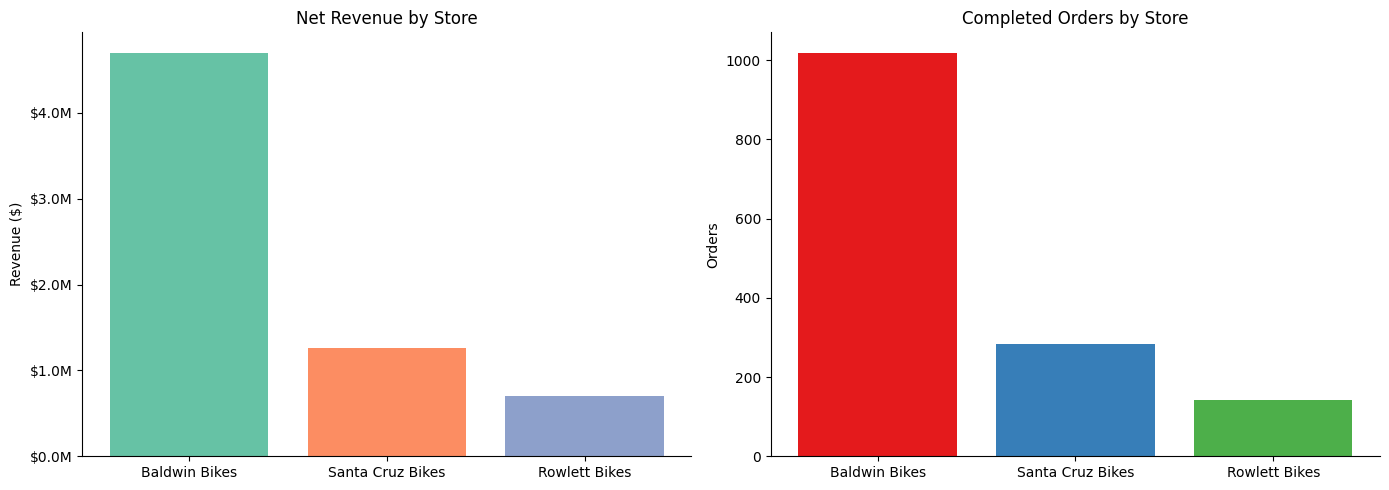

      store_name  total_revenue  total_orders  units_sold
   Baldwin Bikes   4701209.5663          1019        4427
Santa Cruz Bikes   1255491.6489           284        1236
   Rowlett Bikes    705914.0289           142         655


In [25]:
store_rev = (
    completed.groupby("store_name")
    .agg(total_revenue=("revenue","sum"),
         total_orders=("order_id","nunique"),
         units_sold=("quantity","sum"))
    .reset_index().sort_values("total_revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("Set2", 3)
axes[0].bar(store_rev["store_name"], store_rev["total_revenue"], color=colors)
axes[0].set_title("Net Revenue by Store")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))

axes[1].bar(store_rev["store_name"], store_rev["total_orders"], color=sns.color_palette("Set1",3))
axes[1].set_title("Completed Orders by Store")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.savefig("store_revenue.png", dpi=120, bbox_inches="tight")
plt.show()
print(store_rev.to_string(index=False))


## 6. Monthly Revenue & Order Trend

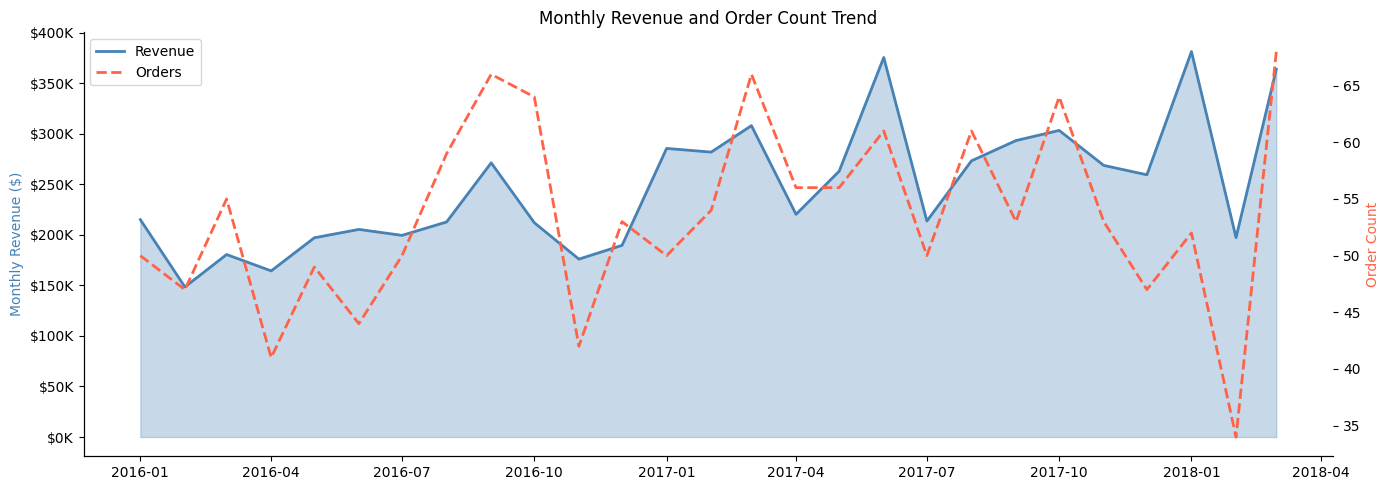

In [26]:
monthly = (
    completed.groupby(completed["order_date"].dt.to_period("M"))
    .agg(revenue=("revenue","sum"), orders=("order_id","nunique"))
    .reset_index()
)
monthly["order_date"] = monthly["order_date"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.fill_between(monthly["order_date"], monthly["revenue"], alpha=0.3, color="steelblue")
ax1.plot(monthly["order_date"], monthly["revenue"], color="steelblue", linewidth=2, label="Revenue")
ax2.plot(monthly["order_date"], monthly["orders"], color="tomato", linewidth=2,
         linestyle="--", label="Orders")

ax1.set_ylabel("Monthly Revenue ($)", color="steelblue")
ax2.set_ylabel("Order Count", color="tomato")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))
plt.title("Monthly Revenue and Order Count Trend")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Brand Performance

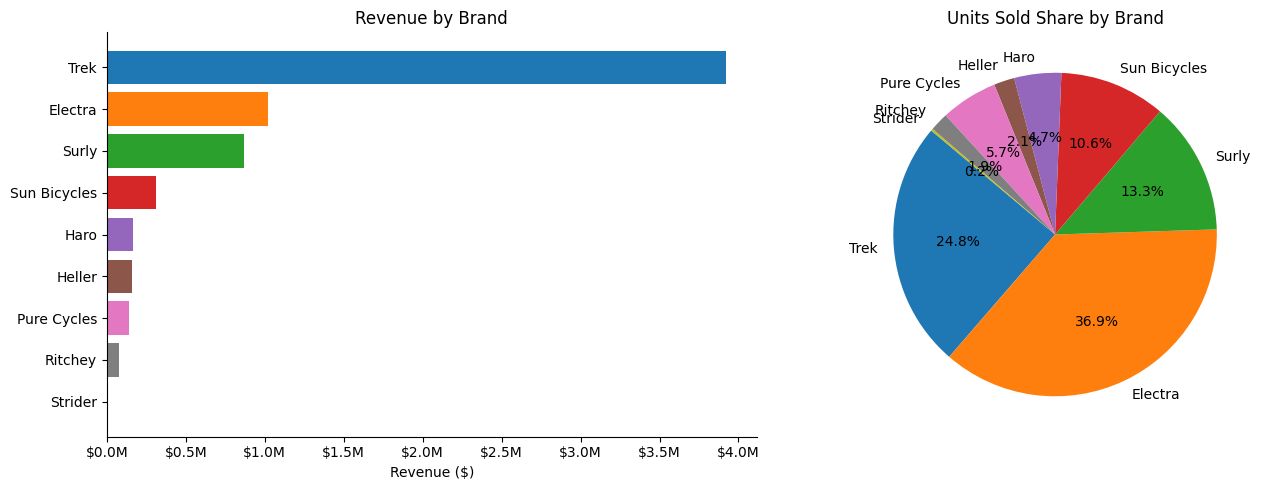

  brand_name      revenue  units
        Trek 3919362.6072   1564
     Electra 1019610.5652   2329
       Surly  868807.2476    838
Sun Bicycles  310418.2308    670
        Haro  163783.2594    297
      Heller  157219.7405    130
 Pure Cycles  143213.5500    360
     Ritchey   78186.4575    117
     Strider    2013.5859     13


In [27]:
brand_rev = (
    completed.groupby("brand_name")
    .agg(revenue=("revenue","sum"), units=("quantity","sum"))
    .reset_index().sort_values("revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(brand_rev["brand_name"], brand_rev["revenue"],
             color=sns.color_palette("tab10", len(brand_rev)))
axes[0].set_title("Revenue by Brand")
axes[0].set_xlabel("Revenue ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
axes[0].invert_yaxis()

axes[1].pie(brand_rev["units"], labels=brand_rev["brand_name"],
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("tab10", len(brand_rev)))
axes[1].set_title("Units Sold Share by Brand")

plt.tight_layout()
plt.savefig("brand_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print(brand_rev.to_string(index=False))


## 8. Category Profitability

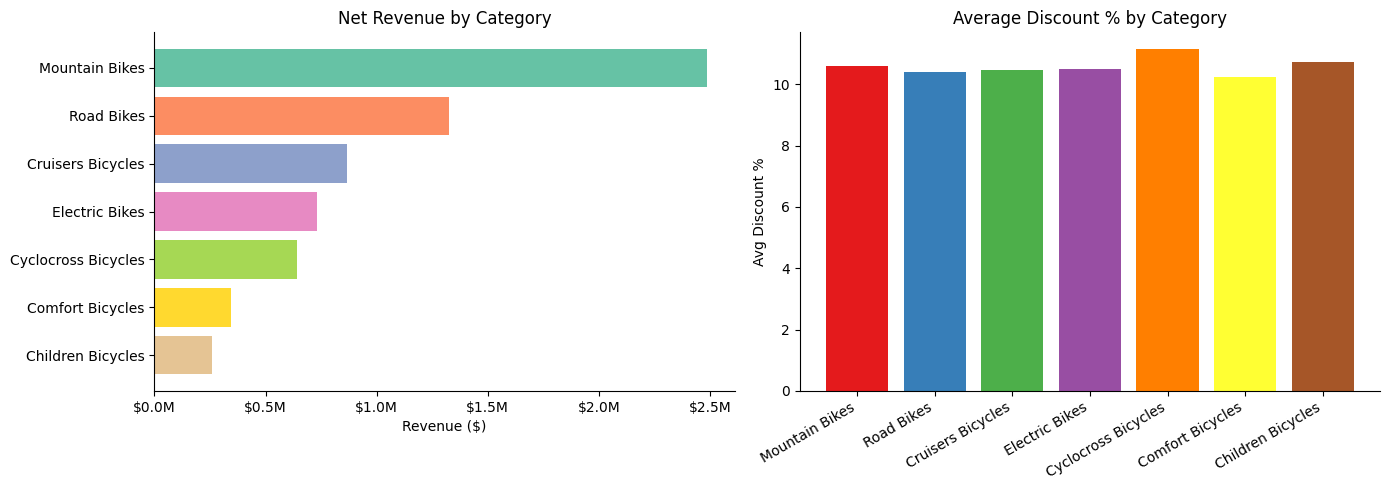

      category_name  gross_revenue  net_revenue  units_sold  avg_discount_pct  discount_lost
     Mountain Bikes     2779955.07 2486420.2641        1607         10.608696    293534.8059
         Road Bikes     1474093.65 1327155.6399         449         10.410000    146938.0101
  Cruisers Bicycles      966455.86  866524.4023        1865         10.476688     99931.4577
     Electric Bikes      817077.48  733493.7451         252         10.517647     83583.7349
Cyclocross Bicycles      723109.80  642584.8253         365         11.142259     80524.9747
   Comfort Bicycles      385688.67  346449.9962         733         10.253086     39238.6738
  Children Bicycles      291629.53  259986.3712        1047         10.740634     31643.1588


In [28]:
oi_cat = (
    order_items
    .merge(products[["product_id","category_id"]], on="product_id")
    .merge(categories, on="category_id")
    .merge(orders[["order_id","order_status"]], on="order_id")
)
oi_comp = oi_cat[oi_cat["order_status"] == 4].copy()
oi_comp["gross"] = oi_comp["list_price"] * oi_comp["quantity"]

cat_profit = (
    oi_comp.groupby("category_name")
    .agg(
        gross_revenue    = ("gross","sum"),
        net_revenue      = ("revenue","sum"),
        units_sold       = ("quantity","sum"),
        avg_discount_pct = ("discount", lambda x: x.mean()*100)
    ).reset_index()
)
cat_profit["discount_lost"] = cat_profit["gross_revenue"] - cat_profit["net_revenue"]
cat_profit = cat_profit.sort_values("net_revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cat_profit["category_name"], cat_profit["net_revenue"],
             color=sns.color_palette("Set2", len(cat_profit)))
axes[0].set_title("Net Revenue by Category")
axes[0].set_xlabel("Revenue ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
axes[0].invert_yaxis()

axes[1].bar(cat_profit["category_name"], cat_profit["avg_discount_pct"],
            color=sns.color_palette("Set1", len(cat_profit)))
axes[1].set_title("Average Discount % by Category")
axes[1].set_ylabel("Avg Discount %")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("category_profitability.png", dpi=120, bbox_inches="tight")
plt.show()
print(cat_profit[["category_name","gross_revenue","net_revenue","units_sold","avg_discount_pct","discount_lost"]].to_string(index=False))


## 9. Staff Performance

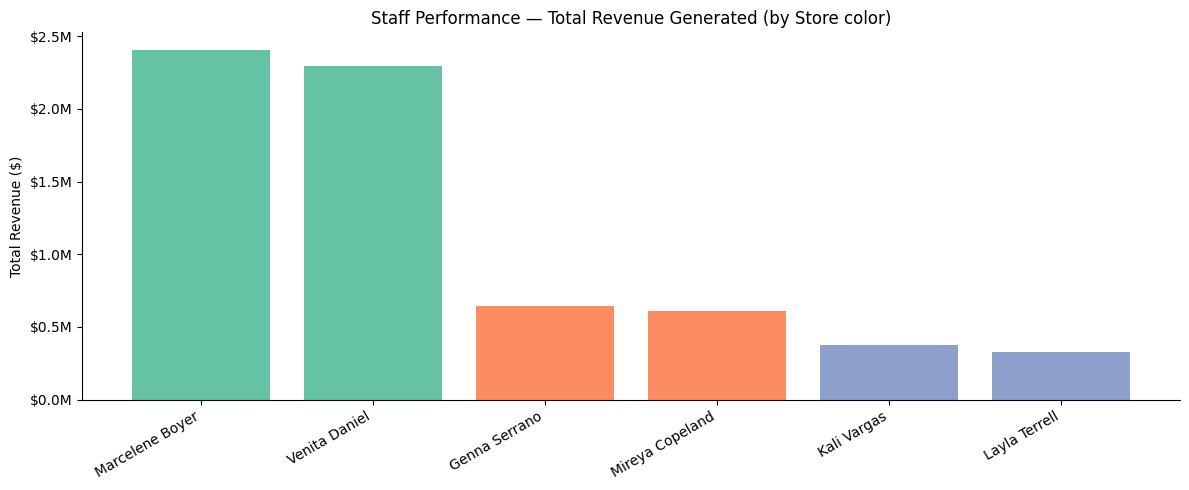

     staff_name       store_name  orders_handled      revenue
Marcelene Boyer    Baldwin Bikes             521 2405217.8490
  Venita Daniel    Baldwin Bikes             498 2295991.7173
  Genna Serrano Santa Cruz Bikes             147  643627.9833
Mireya Copeland Santa Cruz Bikes             137  611863.6656
    Kali Vargas    Rowlett Bikes              71  375464.8000
  Layla Terrell    Rowlett Bikes              71  330449.2289


In [29]:
staff_perf = (
    completed.groupby(["staff_name","store_name"])
    .agg(orders_handled=("order_id","nunique"), revenue=("revenue","sum"))
    .reset_index().sort_values("revenue", ascending=False)
)

palette = sns.color_palette("Set2", 3)
store_list = staff_perf["store_name"].unique().tolist()
colors = [palette[store_list.index(s)] for s in staff_perf["store_name"]]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(staff_perf["staff_name"], staff_perf["revenue"], color=colors)
ax.set_title("Staff Performance — Total Revenue Generated (by Store color)")
ax.set_ylabel("Total Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("staff_performance.png", dpi=120, bbox_inches="tight")
plt.show()
print(staff_perf.to_string(index=False))


## 10. Delayed Shipment Analysis

Total delayed shipments : 458
Max delay (days)        : 2.0
Avg delay (days)        : 1.3


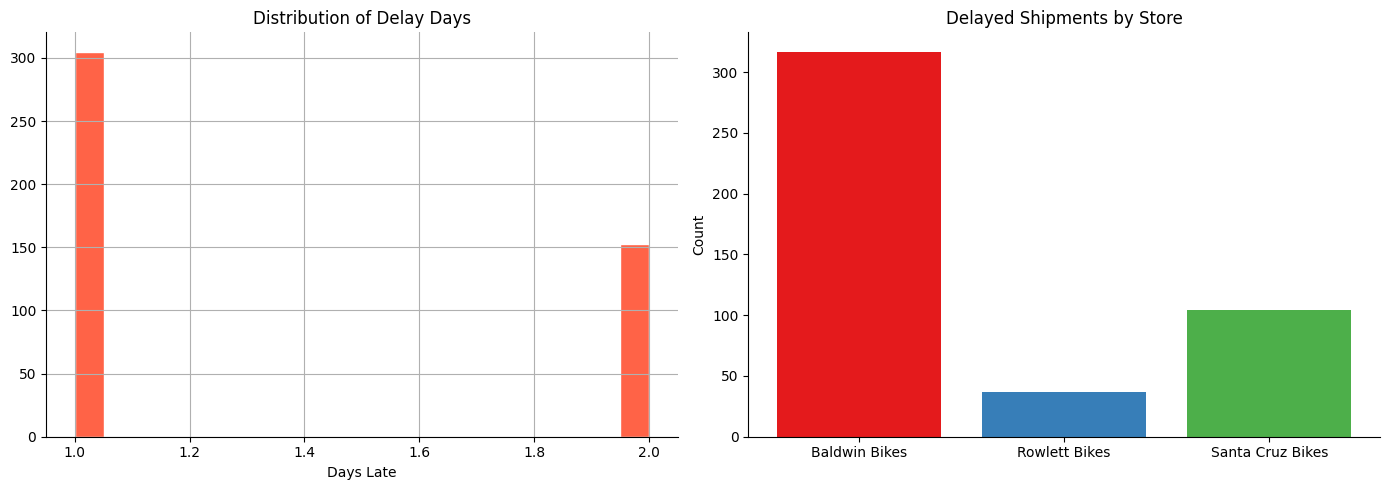

      store_name  count     mean
   Baldwin Bikes    317 1.353312
   Rowlett Bikes     37 1.324324
Santa Cruz Bikes    104 1.278846


In [30]:
orders_d = orders.copy()
orders_d["delay_days"] = (orders_d["shipped_date"] - orders_d["required_date"]).dt.days
delayed = orders_d[orders_d["delay_days"] > 0].merge(stores[["store_id","store_name"]], on="store_id")

print(f"Total delayed shipments : {len(delayed)}")
print(f"Max delay (days)        : {delayed['delay_days'].max()}")
print(f"Avg delay (days)        : {delayed['delay_days'].mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
delayed["delay_days"].hist(bins=20, ax=axes[0], color="tomato", edgecolor="white")
axes[0].set_title("Distribution of Delay Days")
axes[0].set_xlabel("Days Late")

delay_store = delayed.groupby("store_name")["delay_days"].agg(["count","mean"]).reset_index()
axes[1].bar(delay_store["store_name"], delay_store["count"],
            color=sns.color_palette("Set1", 3))
axes[1].set_title("Delayed Shipments by Store")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.savefig("delayed_shipments.png", dpi=120, bbox_inches="tight")
plt.show()
print(delay_store.to_string(index=False))


## 11. Inventory / Stock Analysis

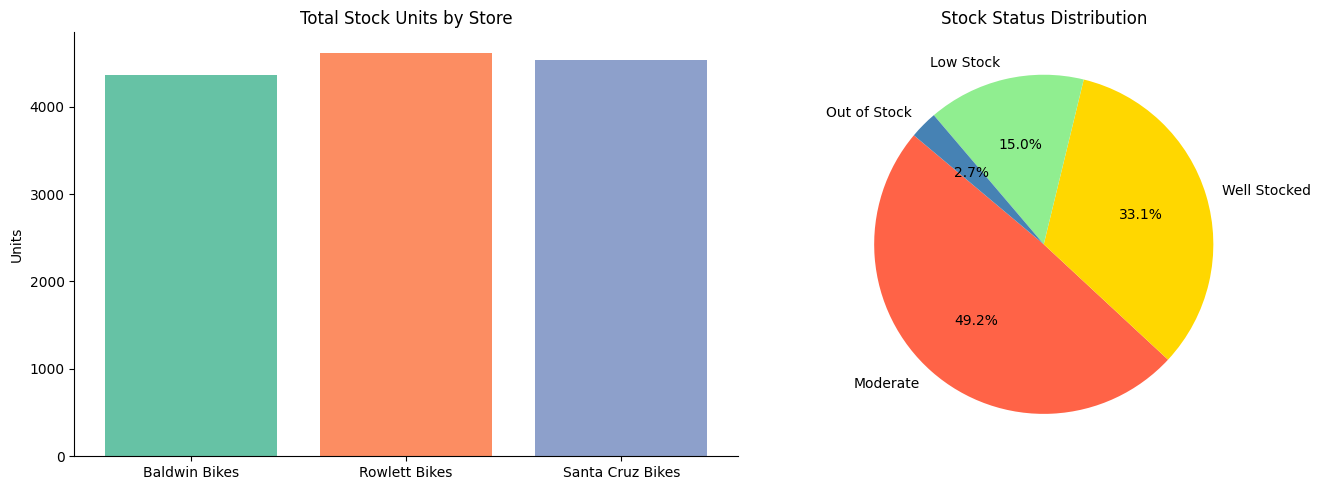

Low/zero stock SKUs: 166
      store_name                                  product_name     category_name  quantity
Santa Cruz Bikes         Surly Ice Cream Truck Frameset - 2016    Mountain Bikes         0
Santa Cruz Bikes         Trek Remedy 29 Carbon Frameset - 2016    Mountain Bikes         0
Santa Cruz Bikes             Trek Farley Alloy Frameset - 2017    Mountain Bikes         0
Santa Cruz Bikes               Trek Fuel EX 5 27.5 Plus - 2017    Mountain Bikes         0
Santa Cruz Bikes                      Trek Emonda SLR 6 - 2018        Road Bikes         0
Santa Cruz Bikes                         Surly Pack Rat - 2018        Road Bikes         0
Santa Cruz Bikes                        Surly Straggler - 2018        Road Bikes         0
Santa Cruz Bikes                       Haro Shredder 20 - 2017 Children Bicycles         0
Santa Cruz Bikes              Electra Townie Original 1 - 2018  Comfort Bicycles         0
   Baldwin Bikes Electra Girl's Hawaii 1 (16-inch) - 2015/2016 Ch

In [31]:
stocks_d = (
    stocks
    .merge(stores[["store_id","store_name"]], on="store_id")
    .merge(products[["product_id","product_name","category_id"]], on="product_id")
    .merge(categories, on="category_id")
)

def stock_status(q):
    if q == 0:   return "Out of Stock"
    if q < 5:    return "Low Stock"
    if q < 20:   return "Moderate"
    return "Well Stocked"

stocks_d["status"] = stocks_d["quantity"].apply(stock_status)
store_stock  = stocks_d.groupby("store_name")["quantity"].sum().reset_index()
status_counts = stocks_d["status"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(store_stock["store_name"], store_stock["quantity"],
            color=sns.color_palette("Set2", 3))
axes[0].set_title("Total Stock Units by Store")
axes[0].set_ylabel("Units")

axes[1].pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
            colors=["tomato","gold","lightgreen","steelblue"], startangle=140)
axes[1].set_title("Stock Status Distribution")
plt.tight_layout()
plt.savefig("inventory_status.png", dpi=120, bbox_inches="tight")
plt.show()

low_stock = stocks_d[stocks_d["quantity"] < 5].sort_values("quantity")
print(f"Low/zero stock SKUs: {len(low_stock)}")
print(low_stock[["store_name","product_name","category_name","quantity"]].head(15).to_string(index=False))


## 12. Customer Demographics

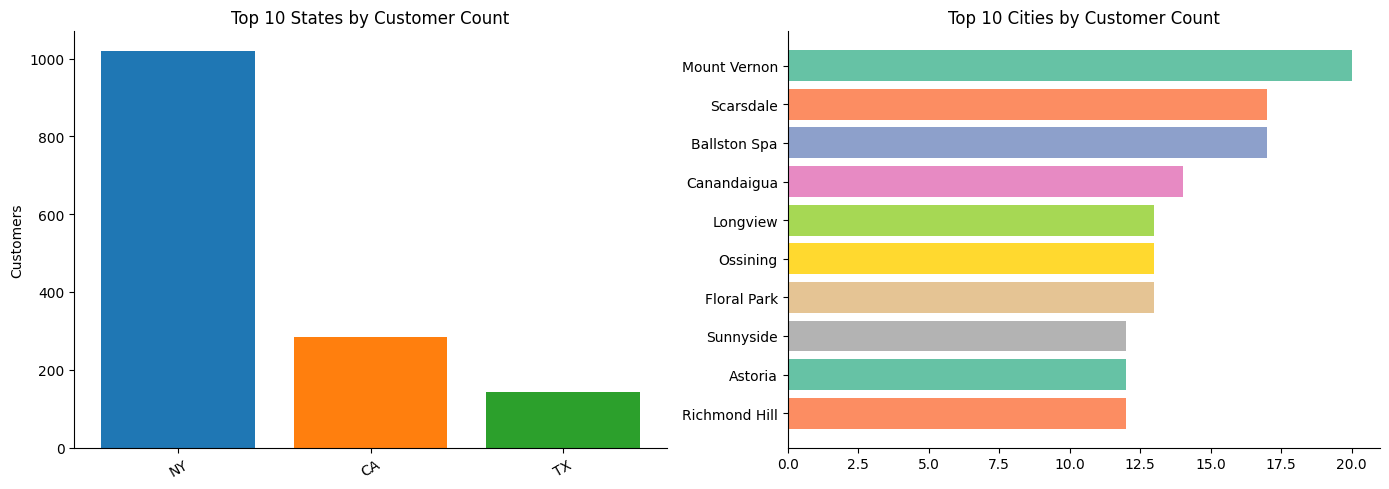

In [32]:
state_counts = customers["state"].value_counts().head(10).reset_index()
state_counts.columns = ["state","customers"]
city_counts  = customers["city"].value_counts().head(10).reset_index()
city_counts.columns = ["city","customers"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(state_counts["state"], state_counts["customers"],
            color=sns.color_palette("tab10", len(state_counts)))
axes[0].set_title("Top 10 States by Customer Count")
axes[0].set_ylabel("Customers")
plt.sca(axes[0]); plt.xticks(rotation=30)

axes[1].barh(city_counts["city"], city_counts["customers"],
             color=sns.color_palette("Set2", len(city_counts)))
axes[1].set_title("Top 10 Cities by Customer Count")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("customer_demographics.png", dpi=120, bbox_inches="tight")
plt.show()


## 13. Customer Lifetime Value (LTV)

Top 10 Customers by Lifetime Value:
   customer_name customer_city customer_state  total_orders  lifetime_value
   Melanie Hayes     Liverpool             NY             1      27050.7182
    Shena Carter  Howard Beach             NY             1      24890.6244
  Abram Copeland     Harlingen             TX             1      24607.0261
    Brigid Sharp   Santa Clara             CA             1      20648.9537
Augustina Joyner  Mount Vernon             NY             1      20509.4254
    Cindi Larson  Howard Beach             NY             1      20177.7457
     Adena Blake  Ballston Spa             NY             1      19329.9492
    Bess Mcbride   Garden City             NY             1      18853.3544
   Penny Acevedo  Ballston Spa             NY             1      18670.9288
   Danielle Bond     Patchogue             NY             1      18553.7300


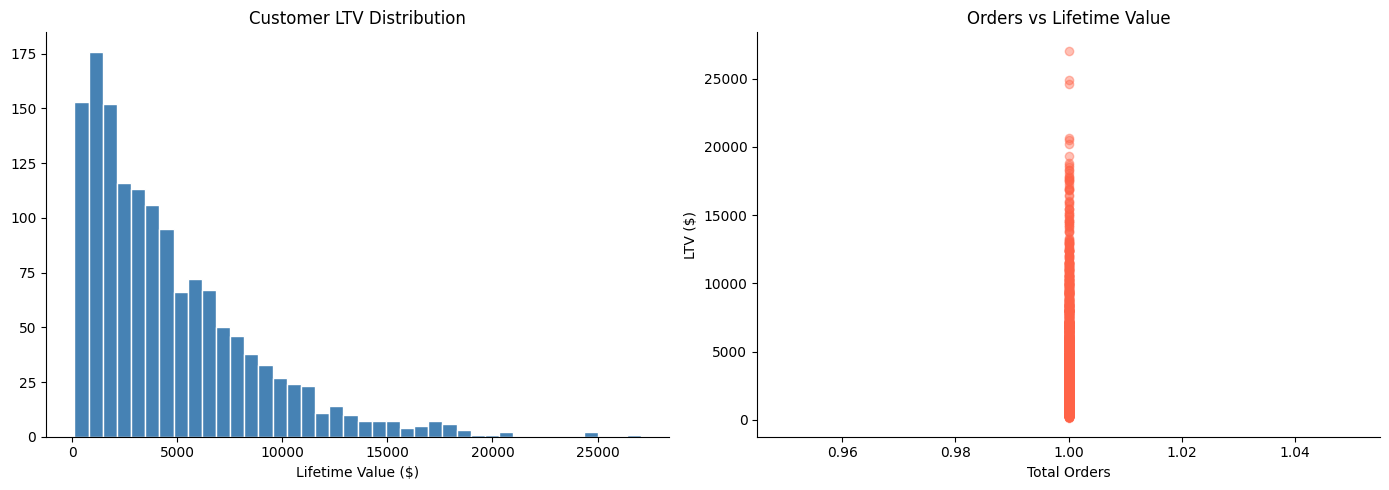

In [33]:
cust_ltv = (
    completed.groupby(["customer_id","customer_name","customer_city","customer_state"])
    .agg(
        total_orders   = ("order_id","nunique"),
        lifetime_value = ("revenue","sum"),
        first_order    = ("order_date","min"),
        last_order     = ("order_date","max")
    ).reset_index()
)
cust_ltv["lifespan_days"] = (cust_ltv["last_order"] - cust_ltv["first_order"]).dt.days.fillna(0)
cust_ltv = cust_ltv.sort_values("lifetime_value", ascending=False)

print("Top 10 Customers by Lifetime Value:")
print(cust_ltv.head(10)[["customer_name","customer_city","customer_state","total_orders","lifetime_value"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cust_ltv["lifetime_value"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Customer LTV Distribution")
axes[0].set_xlabel("Lifetime Value ($)")

axes[1].scatter(cust_ltv["total_orders"], cust_ltv["lifetime_value"], alpha=0.4, color="tomato")
axes[1].set_title("Orders vs Lifetime Value")
axes[1].set_xlabel("Total Orders")
axes[1].set_ylabel("LTV ($)")
plt.tight_layout()
plt.savefig("customer_ltv.png", dpi=120, bbox_inches="tight")
plt.show()


## 14. Customer Segmentation — KMeans Clustering

In [ ]:
# Prepare features
seg_df = cust_ltv[["total_orders","lifetime_value","lifespan_days"]].fillna(0).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(seg_df)

# Elbow + Silhouette
inertias, sil_scores = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), sil_scores, marker="s", color="tomato", linewidth=2)
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.savefig("kmeans_elbow.png", dpi=120, bbox_inches="tight")
plt.show()
print("Silhouette scores:", {k: round(s,3) for k,s in zip(K_range, sil_scores)})


segment_label  count      avg_ltv  avg_orders
    Champions     53 16917.150757         1.0
   High Value    228  9733.875664         1.0
    Mid Value    464  5176.788250         1.0
    Low Value    700  1635.218364         1.0


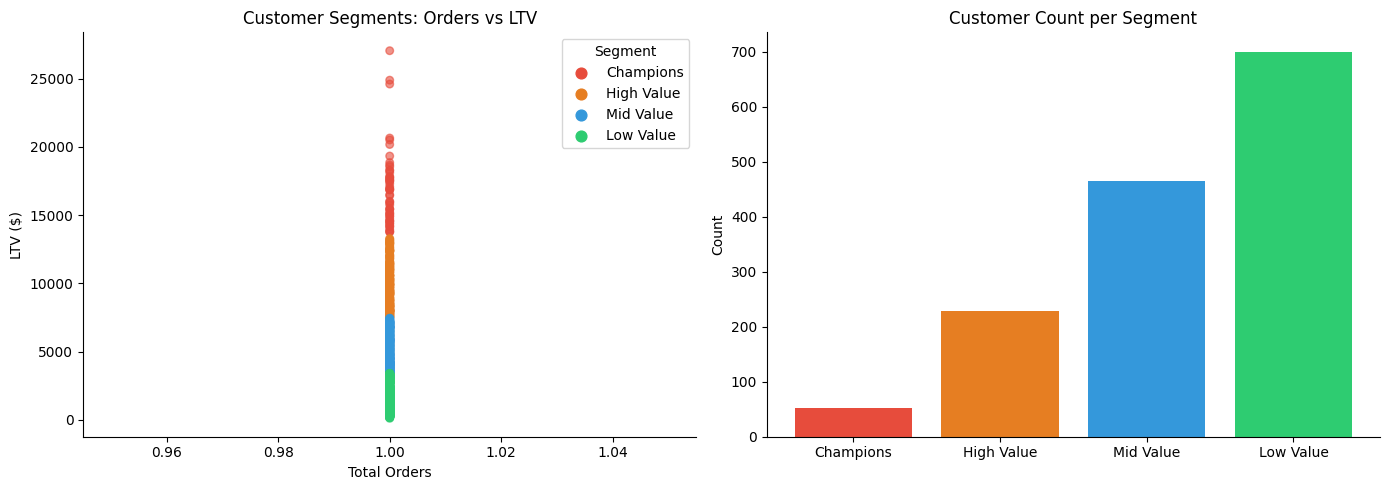

In [ ]:
# Final clustering with k=4
K_BEST = 4
km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
cust_ltv["segment"] = km_final.fit_predict(X_scaled)

seg_mean_ltv = cust_ltv.groupby("segment")["lifetime_value"].mean().sort_values()
label_map = {
    seg_mean_ltv.index[0]: "Low Value",
    seg_mean_ltv.index[1]: "Mid Value",
    seg_mean_ltv.index[2]: "High Value",
    seg_mean_ltv.index[3]: "Champions"
}
cust_ltv["segment_label"] = cust_ltv["segment"].map(label_map)

seg_summary = (
    cust_ltv.groupby("segment_label")
    .agg(count=("customer_id","count"),
         avg_ltv=("lifetime_value","mean"),
         avg_orders=("total_orders","mean"))
    .reset_index().sort_values("avg_ltv", ascending=False)
)
print(seg_summary.to_string(index=False))

palette = {"Champions":"#e74c3c","High Value":"#e67e22",
           "Mid Value":"#3498db","Low Value":"#2ecc71"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(
    cust_ltv["total_orders"], cust_ltv["lifetime_value"],
    c=cust_ltv["segment_label"].map(palette), alpha=0.6, s=30
)
axes[0].set_title("Customer Segments: Orders vs LTV")
axes[0].set_xlabel("Total Orders"); axes[0].set_ylabel("LTV ($)")
for label, color in palette.items():
    axes[0].scatter([], [], c=color, label=label, s=60)
axes[0].legend(title="Segment")

axes[1].bar(seg_summary["segment_label"], seg_summary["count"],
            color=[palette[l] for l in seg_summary["segment_label"]])
axes[1].set_title("Customer Count per Segment")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.savefig("customer_segments.png", dpi=120, bbox_inches="tight")
plt.show()


## 15. Product Model Year Revenue Trend

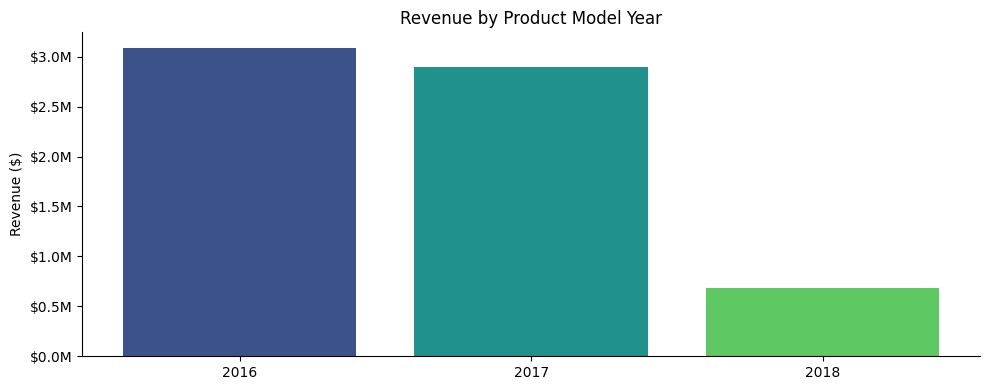

 model_year      revenue  units
       2016 3088887.5471   3379
       2017 2894382.3259   2485
       2018  679345.3711    454


In [ ]:
model_trend = (
    completed.groupby("model_year")
    .agg(revenue=("revenue","sum"), units=("quantity","sum"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(model_trend["model_year"].astype(str), model_trend["revenue"],
       color=sns.color_palette("viridis", len(model_trend)))
ax.set_title("Revenue by Product Model Year")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("model_year_trend.png", dpi=120, bbox_inches="tight")
plt.show()
print(model_trend.to_string(index=False))


## 16. Top 10 Products by Revenue

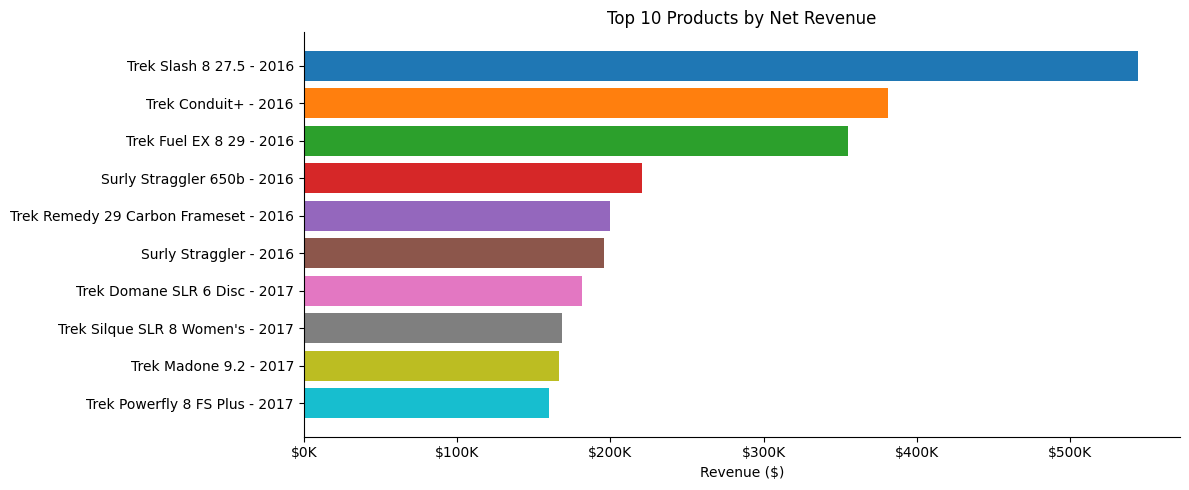

                         product_name brand_name       category_name     revenue  units
             Trek Slash 8 27.5 - 2016       Trek      Mountain Bikes 544318.6392    151
                 Trek Conduit+ - 2016       Trek      Electric Bikes 381148.7295    142
             Trek Fuel EX 8 29 - 2016       Trek      Mountain Bikes 354813.7765    138
          Surly Straggler 650b - 2016      Surly Cyclocross Bicycles 220713.9870    147
Trek Remedy 29 Carbon Frameset - 2016       Trek      Mountain Bikes 199996.8889    123
               Surly Straggler - 2016      Surly Cyclocross Bicycles 195669.6800    141
        Trek Domane SLR 6 Disc - 2017       Trek          Road Bikes 181279.6704     37
     Trek Silque SLR 8 Women's - 2017       Trek          Road Bikes 168674.7405     28
               Trek Madone 9.2 - 2017       Trek          Road Bikes 166599.6668     37
       Trek Powerfly 8 FS Plus - 2017       Trek      Electric Bikes 160249.6795     35


In [ ]:
top_products = (
    completed.groupby(["product_name","brand_name","category_name"])
    .agg(revenue=("revenue","sum"), units=("quantity","sum"))
    .reset_index().sort_values("revenue", ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_products["product_name"].str[:45], top_products["revenue"],
        color=sns.color_palette("tab10", 10))
ax.set_title("Top 10 Products by Net Revenue")
ax.set_xlabel("Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("top_products.png", dpi=120, bbox_inches="tight")
plt.show()
print(top_products[["product_name","brand_name","category_name","revenue","units"]].to_string(index=False))


## 17. Key Business Insights Summary

| # | Insight |
|---|---------|
| 1 | Revenue and order counts show clear seasonal peaks — marketing spend should align with peak months |
| 2 | Top brand drives the majority of revenue — supplier diversification needed to reduce risk |
| 3 | High-discount categories erode margins — discount policy review recommended |
| 4 | Delayed shipments cluster in specific stores — operational bottleneck needs investigation |
| 5 | Champions segment (small % of customers) drives disproportionate revenue — prioritize retention |
| 6 | Low-stock items risk lost sales — implement automated reorder triggers |
| 7 | Newer model years dominate revenue — older inventory should be clearance-priced |
| 8 | Customer concentration in a few states — opportunity for geographic expansion |


## 18. Export Final Insight Tables (CSV)

In [ ]:
import os

store_rev.to_csv("insights_store_revenue.csv", index=False)
cat_profit[["category_name","net_revenue","units_sold","avg_discount_pct","discount_lost"]].to_csv("insights_category_profit.csv", index=False)
staff_perf.to_csv("insights_staff_performance.csv", index=False)
cust_ltv.to_csv("insights_customer_ltv_segments.csv", index=False)
top_products.to_csv("insights_top_products.csv", index=False)

print("Exported insight CSVs:")
for f in sorted(os.listdir(".")):
    if f.startswith("insights_"):
        print(f"  {f}")
print("Done ✓")


Exported insight CSVs:
  insights_category_profit.csv
  insights_customer_ltv_segments.csv
  insights_staff_performance.csv
  insights_store_revenue.csv
  insights_top_products.csv
Done ✓
